# Análisis de tecnologías de la información: Herramientas de desarrollo

## Cargando librerías y los conjuntos de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import utils as u

In [2]:
df_dt = pd.read_parquet('datos/collabtools.parquet')
df_respondents = pd.read_parquet('datos/respondents.parquet')
df_dt_metrics = pd.read_parquet('datos/collab_tools_metrics.parquet')

In [3]:
df_dt.head(2)

,ResponseId,Collab Tools,Relation
0,2,PyCharm,HaveWorkedWith
1,2,Visual Studio Code,HaveWorkedWith


In [4]:
df_respondents.head(2)

,ResponseId,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,YearsCode,YearsCodePro,Country,EdLevel_Group,Age_Group,RemoteWork_Clean
0,2,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,20.0,17.0,GBR,Undergraduate Degree,35-44,Remote
1,3,C#,C#,C#,Firebase Realtime Database,Firebase Realtime Database,Firebase Realtime Database,Google Cloud,Google Cloud,Google Cloud,Visual Studio,Visual Studio,Visual Studio,37.0,27.0,GBR,Postgraduate Degree,45-54,Remote


In [5]:
df_dt_metrics.head(2)

Relation,Admired,HaveWorkedWith,WantToWorkWith,InterestRatio,AdmiredRatio,UsageRate,InterestRate,AdmiredRate,GrowthPotential,NetInterest,ConversionPotential
Collab Tools,,,,,,,,,,,
Android Studio,4672,9379,6132,0.653801,0.498134,0.162852,0.106473,0.081122,-3247,-0.346199,0.127186
BBEdit,302,506,366,0.723320,0.596838,0.008786,0.006355,0.005244,-140,-0.276680,0.006411


## Herramientas principales

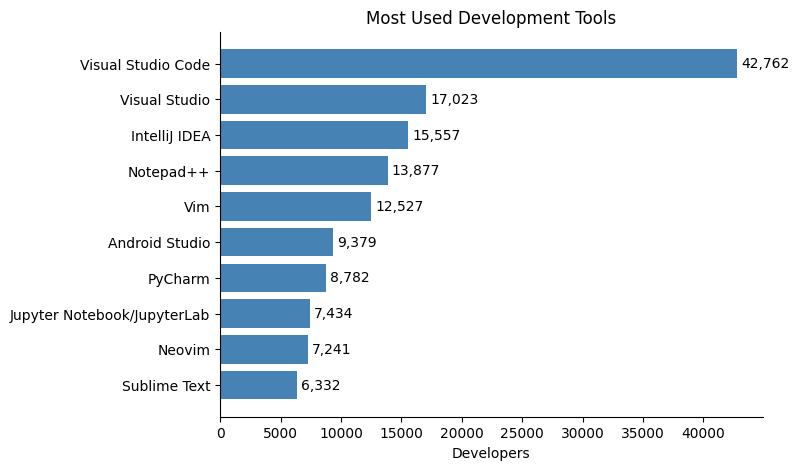

In [6]:
ax_dt_have = u.bars_plot(df_dt_metrics, 'HaveWorkedWith', 'Collab Tools', 'Most Used Development Tools')
plt.show()

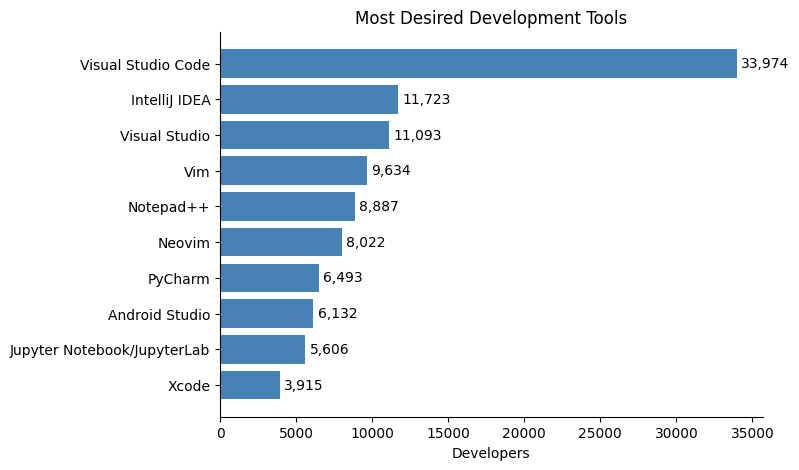

In [7]:
ax_dt_want = u.bars_plot(df_dt_metrics, 'WantToWorkWith', 'Collab Tools', 'Most Desired Development Tools')
plt.show()

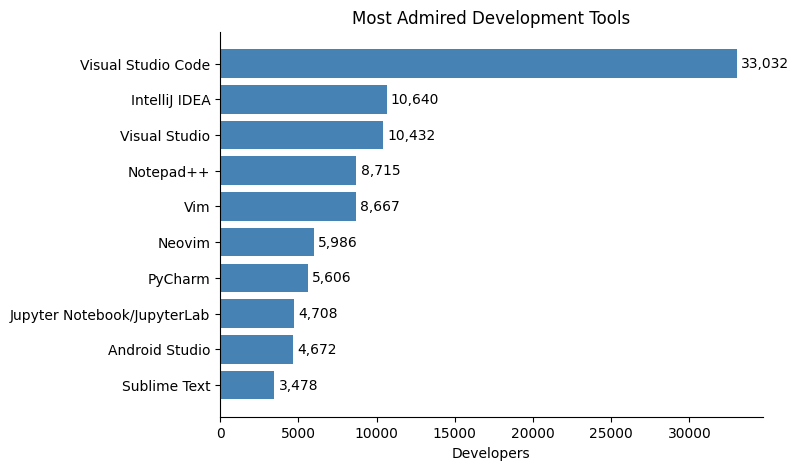

In [8]:
ax_dt_adm = u.bars_plot(df_dt_metrics, 'Admired', 'Collab Tools', 'Most Admired Development Tools')
plt.show()

- Visual Studio Code, Visual Studio e Intellij IDEA son las herramientas de desarrollo mas usadas, admiradas y con mas interes futuro, esto sugiere una alta alineación entre adopción del mercado y preferencia de los desarrolladores.
- Mientras visual Studio Code se mantiene en el top 1, Intellij IDEA pasa a ser el top 2 en admiracion e interes futuro y Visual Studio al top 3.
- Sublime Text ocupa el top 10 en uso y admiración, sin embargo, no aparece dentro del top 10 en la gráfica de interes. Esto indica que, aunque no genera un alto interés entre los desarrolladores, sí es una herramienta ampliamente utilizada en el último año y bien valorada por sus usuarios.

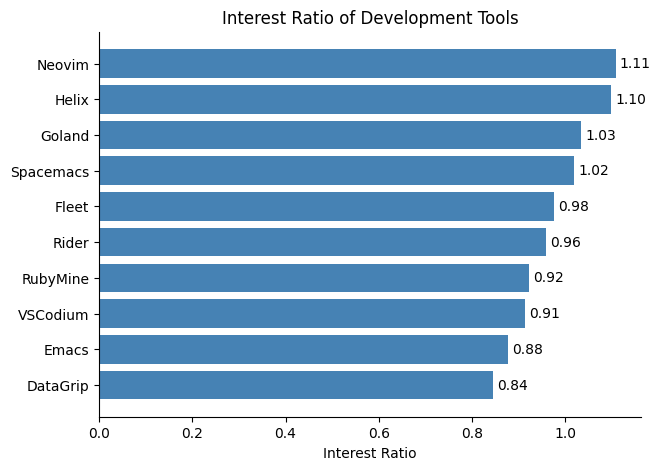

In [9]:
ax_int_ratio = u.bars_plot(df_dt_metrics, 'InterestRatio', 'Collab Tools', 'Interest Ratio of Development Tools', fmt = '{:.2f}', xlabel='Interest Ratio')
plt.show()

Neovim, Helix, Goland y Spacemacs tienen un indice de preferencia mayor a 1, indicando alta alineacion entre uso actual e interes futuro.

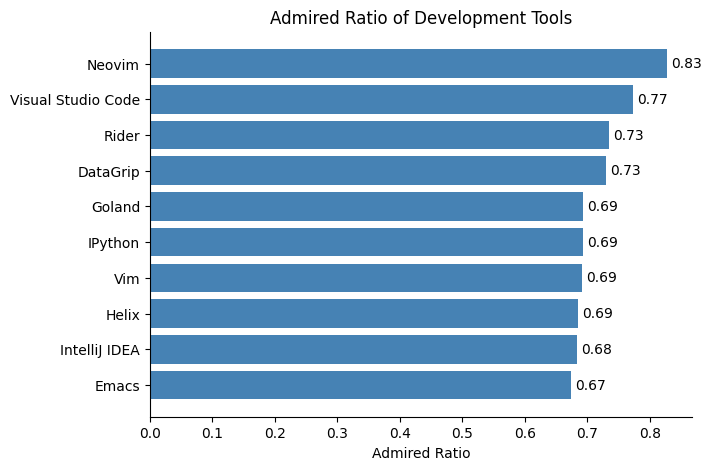

In [10]:
ax_adm_ratio = u.bars_plot(df_dt_metrics, 'AdmiredRatio', 'Collab Tools', 'Admired Ratio of Development Tools', fmt = '{:.2f}', xlabel='Admired Ratio')
plt.show()

- Neovim presenta la mayor tasa de admiración (0.83), lo que indica una fuerte alineación entre uso y admiración. Esto sugiere un alto nivel de satisfacción entre los desarrolladores que utilizan esta herramienta.
- Visual Studio Code, Rider y DataGrip también muestran índices de admiración elevados (0.77, 0.73 y 0.73 respectivamente), lo que refleja una percepción positiva y altos niveles de satisfacción entre los desarrolladores que trabajan con estas herramientas.

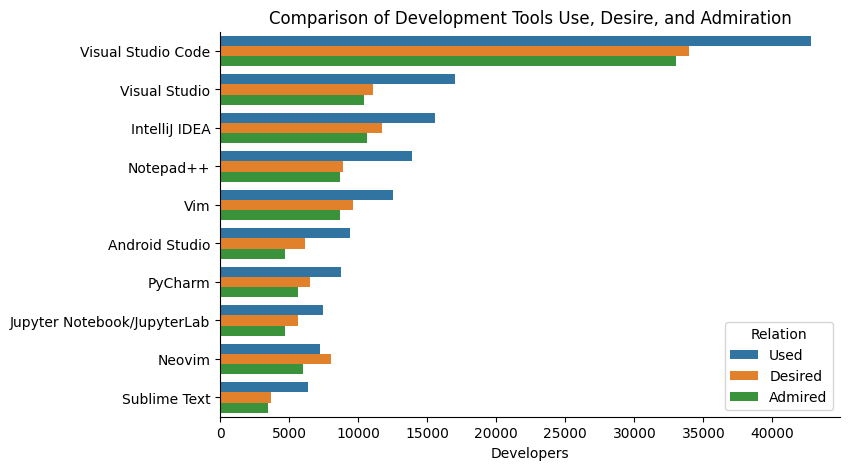

In [11]:
ax_comp = u.bar_comparative_plot(df_dt_metrics, 'Collab Tools', 'Comparison of Development Tools Use, Desire, and Admiration')
plt.show()

- Visual Studio Code es la herramienta más utilizada en el mercado durante el último año; además, presenta altos niveles de interés y admiración, posicionándose como la herramienta líder.
- Si bien Sublime Text no forma parte del top 10 en interés, se observa una proporción similar entre interés y admiración.
- Neovim presenta una mayor cantidad de usuarios interesados en la herramienta que de usuarios que la han utilizado en el último año.

In [12]:
x_median = df_dt_metrics['HaveWorkedWith'].median()
df_plot = u.assign_quadrant(
    df_dt_metrics, 
    'HaveWorkedWith', 
    'InterestRatio', 
    x_median, 
    1, 
    'MarketQuadrant',
    'Growth',
    'Emerging',
    'Declining',
    'Mature'
)

growth   = df_plot[df_plot['MarketQuadrant'] == 'Growth'].nlargest(4, 'HaveWorkedWith')
emerging  = df_plot[df_plot['MarketQuadrant'] == 'Emerging'].nlargest(4, 'InterestRatio')
mature    = df_plot[df_plot['MarketQuadrant'] == 'Mature'].nlargest(4, 'HaveWorkedWith')
declining = df_plot[df_plot['MarketQuadrant'] == 'Declining'].nsmallest(4, 'InterestRatio')

label_df = pd.concat([growth, emerging, mature, declining])

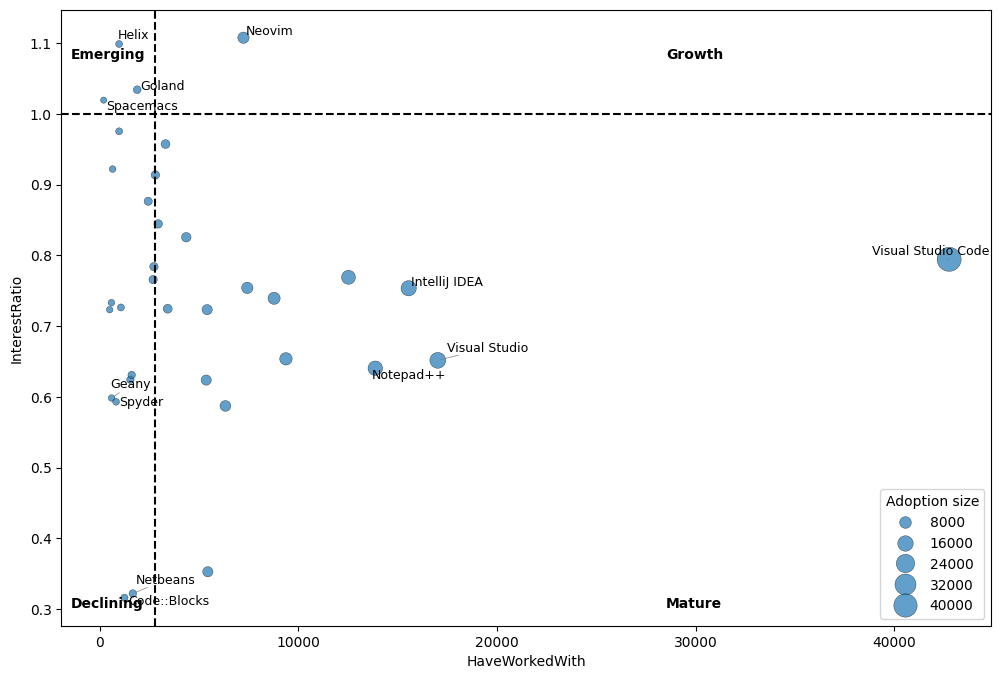

In [13]:
ax_have_prefer = u.quadrant_chart(df_dt_metrics, 'HaveWorkedWith', 'InterestRatio', x_median, 1, label_df, 'Growth', 'Emerging', 'Declining', 'Mature')
plt.show()

Plataformas como Visual Studio, Intellij IDEA y Visual Studio Code se posicionan como tecnologías maduras, con un crecimiento menos explosivo debido a su alta base de usuarios, siendo Visual Studio Code la tecnologia con mayor base de usuarios en esta muestra.
Por otro lado, Neovim se presenta como una tecnología con un alto *Interest Ratio*, posicionandose como una tecnología en crecimiento.
Tecnologias emergentes como Helix y Goland presentan un alto *Interest Ratio* pero baja base de usuarios, lo que los comvierte en oportunidades de adopción pero con mayor incertidumbre.

In [14]:
x_median = df_plot['InterestRatio'].median()
y_median = df_plot['AdmiredRatio'].median()

df_plot = u.assign_quadrant(
    df_plot,
    'InterestRatio',
    'AdmiredRatio',
    x_median,
    y_median,
    'PerceptionQuadrant',
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)

leaders = df_plot[df_plot['PerceptionQuadrant'] =='Leaders'].nlargest(4, 'AdmiredRatio')
loved   = df_plot[df_plot['PerceptionQuadrant'] == 'Loved Niche'].nlargest(4, 'AdmiredRatio')
trendy  = df_plot[df_plot['PerceptionQuadrant'] == 'Trendy'].nlargest(4, 'InterestRatio')
weak    = df_plot[df_plot['PerceptionQuadrant'] == 'Weak'].nsmallest(4, 'AdmiredRatio')

label_df = pd.concat([leaders, loved, trendy, weak])

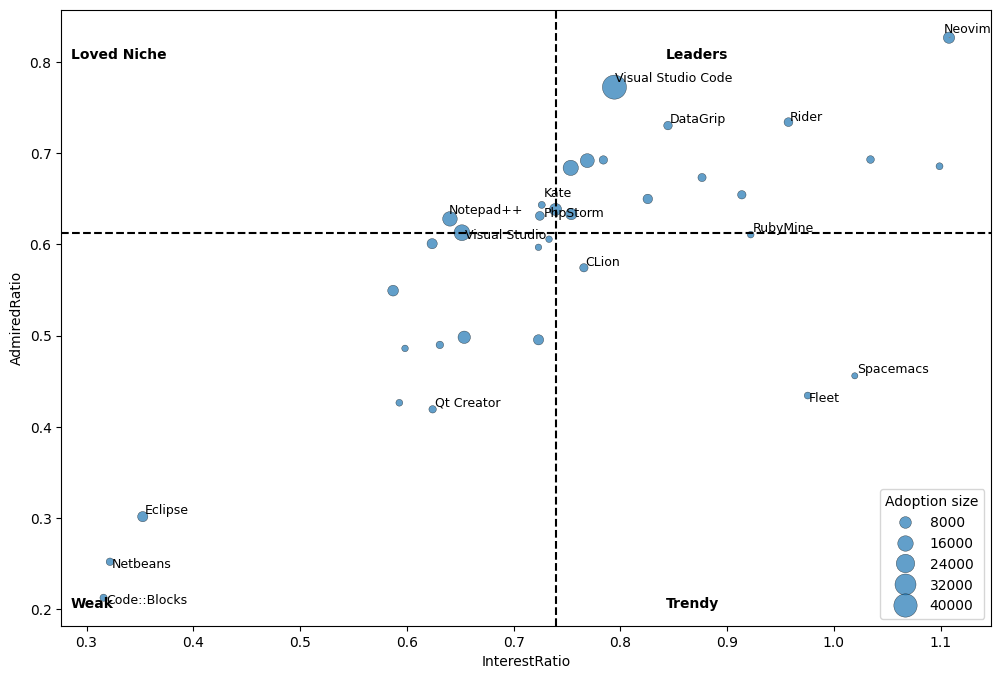

In [15]:
ax_prefer_adm = u.quadrant_chart(
    df_plot,
    'InterestRatio',
    'AdmiredRatio',
    x_median,
    y_median,
    label_df,
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)
plt.show()

- Visual Studio Code domina el ecosistema, al combinar alta adopción, interés y satisfacción, lo que refleja una fuerte alineación con las necesidades actuales del mercado.
- Neovim, Rider y DataGrip se posicionan como herramientas líderes emergentes, mostrando altos niveles tanto de interés como de admiración, lo que sugiere una adopción sostenida en el futuro.
- Fleet y Spacemacs destacan por su alto interés, pero menor nivel de satisfacción, lo que indica que generan expectativa en los desarrolladores, aunque aún no consolidan su propuesta de valor.
- Kate, PhpStorm, Notepad++ y Visual Studio presentan altos niveles de admiración, pero menor interés relativo, posicionándose como herramientas bien valoradas por sus usuarios actuales, aunque con menor atracción hacia nuevos usuarios.
- Eclipse, NetBeans, Qt Creator y Code::Blocks muestran bajos niveles tanto de interés como de admiración, lo que sugiere una pérdida de relevancia y un limitado potencial de adopción futura.

In [16]:
x_median = df_plot['InterestRate'].quantile(0.75)
y_median = df_plot['AdmiredRate'].quantile(0.75)

df_plot = u.assign_quadrant(
    df_plot,
    'InterestRate',
    'AdmiredRate',
    x_median,
    y_median,
    'PerceptionQuadrant2',
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)

In [17]:
leaders = df_plot[df_plot['PerceptionQuadrant2'] =='Leaders'].nlargest(4, 'AdmiredRate')
loved   = df_plot[df_plot['PerceptionQuadrant2'] == 'Loved Niche'].nlargest(4, 'AdmiredRate')
trendy  = df_plot[df_plot['PerceptionQuadrant2'] == 'Trendy'].nlargest(4, 'InterestRate')
weak    = df_plot[df_plot['PerceptionQuadrant2'] == 'Weak'].nsmallest(4, 'AdmiredRate')

label_df = pd.concat([leaders, loved, trendy, weak])

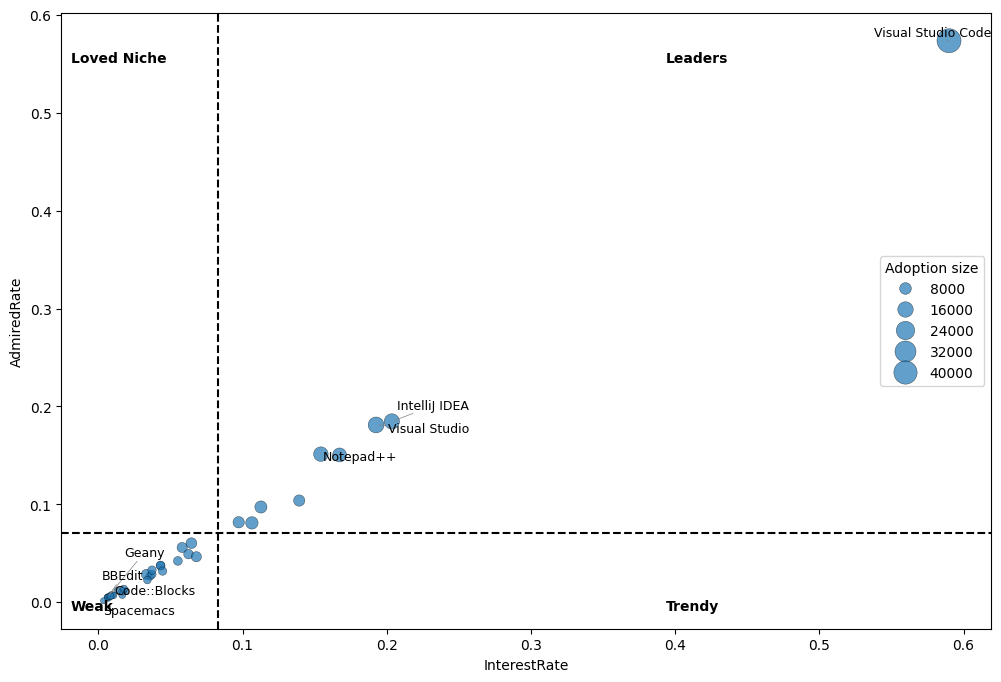

In [18]:
ax_intr_admr = u.quadrant_chart(
    df_plot,
    'InterestRate',
    'AdmiredRate',
    x_median,
    y_median,
    label_df,
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)
plt.show()

- Visual Studio Code se posiciona como líder indiscutible, siendo la única herramienta que combina niveles sobresalientes de interés y admiración bajo un criterio más exigente (Q3), lo que refuerza su dominio en el mercado.
- IntelliJ IDEA y Visual Studio muestran buenos niveles de interés y admiración, pero no alcanzan el umbral de herramientas líderes, posicionándose como soluciones consolidadas, aunque no dominantes.
- La mayoría de herramientas se concentran por debajo del tercer cuartil en ambos indicadores, lo que sugiere un mercado altamente centralizado en pocas tecnologías destacadas.
- Notepad++ presenta niveles moderados de adopción y valoración, manteniéndose como una herramienta estable pero sin señales claras de crecimiento significativo.
-Herramientas como Geany, BBEdit, Code::Blocks y Spacemacs se ubican en el cuadrante de bajo interés y baja admiración, reflejando una adopción limitada y baja preferencia entre desarrolladores.

In [19]:
comparison = (
    df_plot[
        ['MarketQuadrant', 'PerceptionQuadrant']
    ]
    .reset_index()
    .sort_values(['MarketQuadrant', 'PerceptionQuadrant'])
)

crosstab = pd.crosstab(
    df_plot['MarketQuadrant'],
    df_plot['PerceptionQuadrant']
)

crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0)
crosstab_pct

PerceptionQuadrant,Leaders,Loved Niche,Trendy,Weak
MarketQuadrant,,,,
Declining,0.142857,0.071429,0.214286,0.571429
Emerging,0.666667,0.000000,0.333333,0.000000
Growth,1.000000,0.000000,0.000000,0.000000
Mature,0.529412,0.176471,0.000000,0.294118


- Todas las plataformas clasificadas en el cuadrante de crecimiento también son percibidas como líderes, lo que sugiere una fuerte alineación entre expansión en el mercado y percepción positiva entre los desarrolladores.
- La mayoría de las plataformas emergentes son percibidas como líderes (67%), mientras que el resto se posiciona como tendencias emergentes (33%). Esto sugiere que muchas tecnologías nuevas ya cuentan con una percepción positiva entre los desarrolladores.
- Las plataformas maduras presentan percepciones más diversas: aunque más de la mitad siguen siendo consideradas líderes, una proporción relevante aparece como tecnologías de nicho apreciadas o incluso con percepción débil.
- Las plataformas en declive muestran la mayor proporción de percepción débil (50%), lo que sugiere que la pérdida de relevancia en el mercado suele acompañarse de una menor valoración por parte de los desarrolladores.

In [20]:
market_score = {
    'Growth': 3,
    'Emerging': 2,
    'Mature': 1,
    'Declining': 0
}

perception_score = {
    'Leaders': 3,
    'Loved Niche': 2,
    'Trendy': 1,
    'Weak': 0
}

df_plot['MarketScore'] = df_plot['MarketQuadrant'].map(market_score)
df_plot['PerceptionScore'] = df_plot['PerceptionQuadrant'].map(perception_score)

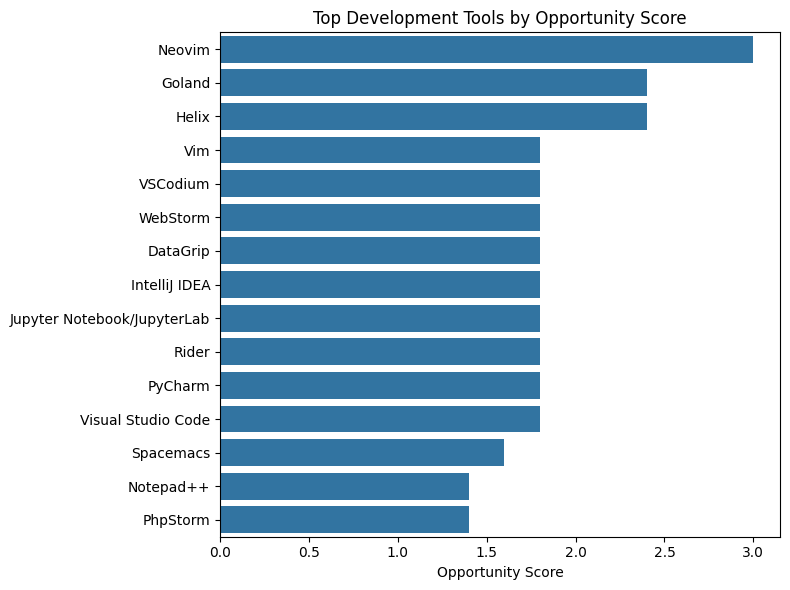

In [21]:
df_plot['OpportunityScore'] = (
    df_plot['MarketScore'] * 0.6 +
    df_plot['PerceptionScore'] * 0.4
)

ranking = (
    df_plot
    .sort_values('OpportunityScore', ascending=False).reset_index()
    [['Collab Tools', 'MarketQuadrant', 'PerceptionQuadrant', 'OpportunityScore']]
)

top = 15

df_rank = (
    df_plot
    .sort_values('OpportunityScore', ascending=False)
    .head(top)
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=df_rank,
    x='OpportunityScore',
    y='Collab Tools'
)

plt.title('Top Development Tools by Opportunity Score')
plt.xlabel('Opportunity Score')
plt.ylabel('')

plt.tight_layout()
plt.show()

- Neovim presenta el mayor Opportunity Score (3.0), lo que indica que el interés por trabajar con esta herramienta es considerablemente mayor que su uso actual. Esto sugiere un alto potencial de crecimiento y adopción futura entre los desarrolladores.
- Goland y Helix muestran también niveles elevados de oportunidad (2.4), lo que sugiere que existe un interés significativo por parte de los desarrolladores que aún no se refleja completamente en su nivel de adopción.
- Varias herramientas ampliamente utilizadas como Visual Studio Code, IntelliJ IDEA y PyCharm presentan un Opportunity Score cercano a 1.8, lo que indica que, a pesar de su adopción consolidada, continúan generando interés entre desarrolladores que aún no las utilizan.

Las herramientas con mayor Opportunity Score tienden a ser tecnologías con comunidades entusiastas pero menor adopción general, como Neovim o Helix. En contraste, herramientas ampliamente consolidadas como Visual Studio Code o IntelliJ IDEA muestran oportunidades de crecimiento más moderadas, ya que gran parte de los desarrolladores interesados ya las utilizan.

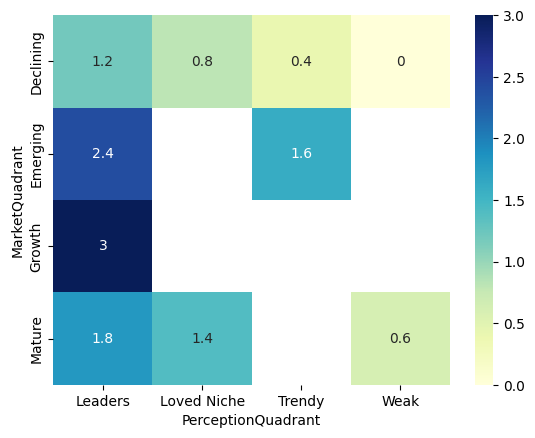

In [22]:
pivot = (
    df_plot
    .pivot_table(
        values = 'OpportunityScore',
        index = 'MarketQuadrant',
        columns = 'PerceptionQuadrant'
    )
)

sns.heatmap(pivot, annot = True, cmap = 'YlGnBu')
plt.show()

In [23]:
df_plot['AlignmentGap'] = (
    df_plot['PerceptionScore'] - df_plot['MarketScore']
)

df_plot.sort_values('AlignmentGap', ascending=False)['AlignmentGap'].head(5)

Collab Tools
Emacs            3
IPython          3
IntelliJ IDEA    2
Vim              2
VSCodium         2
Name: AlignmentGap, dtype: int64

RubyMine, IPython y Emacs presentan una alineacion elevada, superior a su posición en el mercado, lo que indica posibles oportunidades de crecimiento impulsadas por entusiasmo y admiración de la comunidad.

In [24]:
df_plot.sort_values('AlignmentGap')['AlignmentGap'].head(5)

Collab Tools
Android Studio   -1
Eclipse          -1
Nano             -1
Sublime Text     -1
Spacemacs        -1
Name: AlignmentGap, dtype: int64

Android Studio y Eclipse presentan una alineación negativa, indicando menos oportunidades de crecimiento dentro del ecosistema.

In [25]:
df_dt_exp = (
    df_dt
    .merge(df_respondents[['ResponseId', 'YearsCodePro', 'Age_Group', 'RemoteWork_Clean', 'EdLevel_Group', 'Country']], on = 'ResponseId')
)
df_dt_exp.head()

,ResponseId,Collab Tools,Relation,YearsCodePro,Age_Group,RemoteWork_Clean,EdLevel_Group,Country
0,2,PyCharm,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR
1,2,Visual Studio Code,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR
2,2,WebStorm,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR
3,3,Visual Studio,HaveWorkedWith,27.0,45-54,Remote,Postgraduate Degree,GBR
4,5,Vim,HaveWorkedWith,NaN,18-24,Not specified,No Formal Degree,NOR


In [26]:
df_analysis = df_dt_exp.merge(
    df_plot.reset_index()[['Collab Tools', 'MarketQuadrant', 'PerceptionQuadrant', 
             'MarketScore', 'PerceptionScore', 'OpportunityScore', 'AlignmentGap']],
    on = 'Collab Tools',
    how = 'left'
)
df_analysis.head()

,ResponseId,Collab Tools,Relation,YearsCodePro,Age_Group,RemoteWork_Clean,EdLevel_Group,Country,MarketQuadrant,PerceptionQuadrant,MarketScore,PerceptionScore,OpportunityScore,AlignmentGap
0,2,PyCharm,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR,Mature,Leaders,1,3,1.8,2
1,2,Visual Studio Code,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR,Mature,Leaders,1,3,1.8,2
2,2,WebStorm,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR,Mature,Leaders,1,3,1.8,2
3,3,Visual Studio,HaveWorkedWith,27.0,45-54,Remote,Postgraduate Degree,GBR,Mature,Loved Niche,1,2,1.4,1
4,5,Vim,HaveWorkedWith,NaN,18-24,Not specified,No Formal Degree,NOR,Mature,Leaders,1,3,1.8,2


In [27]:
df_analysis['MarketQuadrant'].isna().sum()

np.int64(0)

In [28]:
df_plot.reset_index()['Collab Tools'].nunique() == len(df_plot)

True

In [29]:
len(df_dt_exp) == len(df_analysis)

True

In [30]:
(
    df_analysis[df_analysis['Relation'] == 'HaveWorkedWith']
    .groupby('MarketQuadrant')['YearsCodePro']
    .mean()
    .sort_values()
)

MarketQuadrant
Growth        7.806060
Emerging      9.657944
Mature        9.977344
Declining    10.576240
Name: YearsCodePro, dtype: float64

Se observa que las herramientras en crecimiento (Growth) tienen el menor promedio de experiencia profesional, por otro lado, las herramientas emergentes, maduras y en declive presentan promedio de experiencia profesional cercanad (9-11 años), lo que sugiere cierta influencia de los niveles de experiencia en las percepciones y adopciones de herramientas.

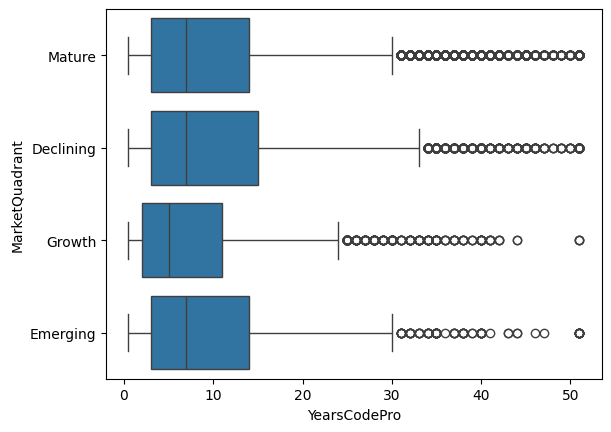

In [31]:
sns.boxplot(
    data=df_analysis[df_analysis['Relation'] == 'HaveWorkedWith'],
    x = 'YearsCodePro',
    y = 'MarketQuadrant'
)
plt.show()

En general, la distribución de años de experiencia profesional es similar entre los distintos cuadrantes del mercado (Mature, Emerging y Declining). Las medianas y rangos intercuartílicos presentan valores cercanos, lo que sugiere que el nivel de experiencia de los desarrolladores no varía significativamente según la posición de las plataformas en el mercado. Además, en todos los cuadrantes se observan outliers con alta experiencia, indicando la presencia de profesionales muy experimentados en cada categoría.

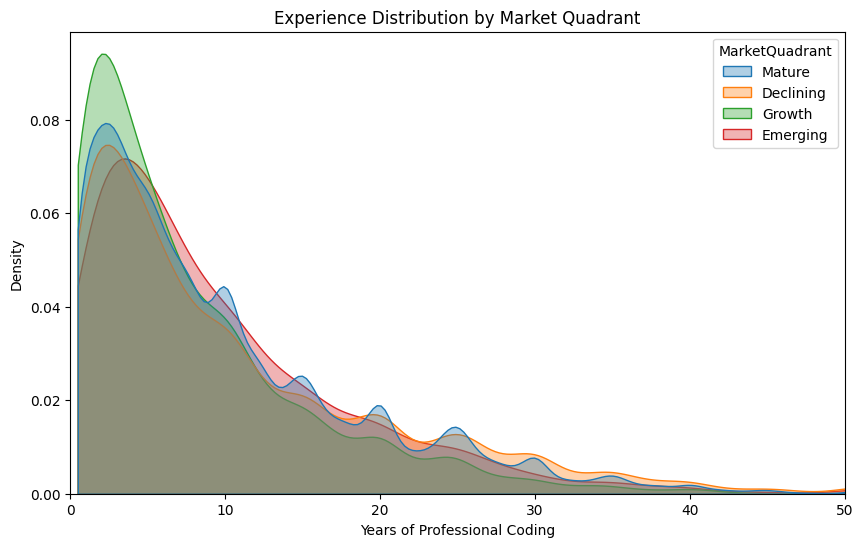

In [32]:
df_plot2 = df_analysis[df_analysis['Relation'] == 'HaveWorkedWith']

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df_plot2,
    x = 'YearsCodePro',
    hue = 'MarketQuadrant',
    common_norm = False,
    fill = True,
    alpha = 0.35,
    cut = 0
)
plt.xlim(0,50)
plt.xlabel('Years of Professional Coding')
plt.ylabel('Density')
plt.title('Experience Distribution by Market Quadrant')
plt.show()

- Alta concentración en baja experiencia (0–5 años) en todos los cuadrantes, lo que indica que el mercado está fuertemente dominado por talento jr. en etapas iniciales, independientemente del tipo de tecnología
- Tecnologías en crecimiento atraen talento más joven como muestra el cuadrante Growth, en el cual se observa el pico más pronunciado en los primeros años, sugiriendo que estas tecnologías están siendo adoptadas principalmente por desarrolladores nuevos o en formación
- Mature y Declining tienen colas más largas hacia la derecha, lo que indica una mayor presencia de profesionales con muchos años de experiencia, reflejando tecnologías más establecidas o con menor renovación generacional

In [33]:
pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize = 'index'
)

PerceptionQuadrant,Leaders,Loved Niche,Trendy,Weak
Age_Group,,,,
18-24,0.651916,0.141859,0.033945,0.172280
25-34,0.650066,0.158158,0.020745,0.171032
35-44,0.614996,0.193076,0.017548,0.174380
45-54,0.570332,0.216142,0.018510,0.195016
55-64,0.514563,0.248307,0.018004,0.219127
65+,0.467172,0.262147,0.012325,0.258355
Under 18,0.637369,0.147688,0.033549,0.181395
Unknown,0.567332,0.184844,0.014849,0.232975


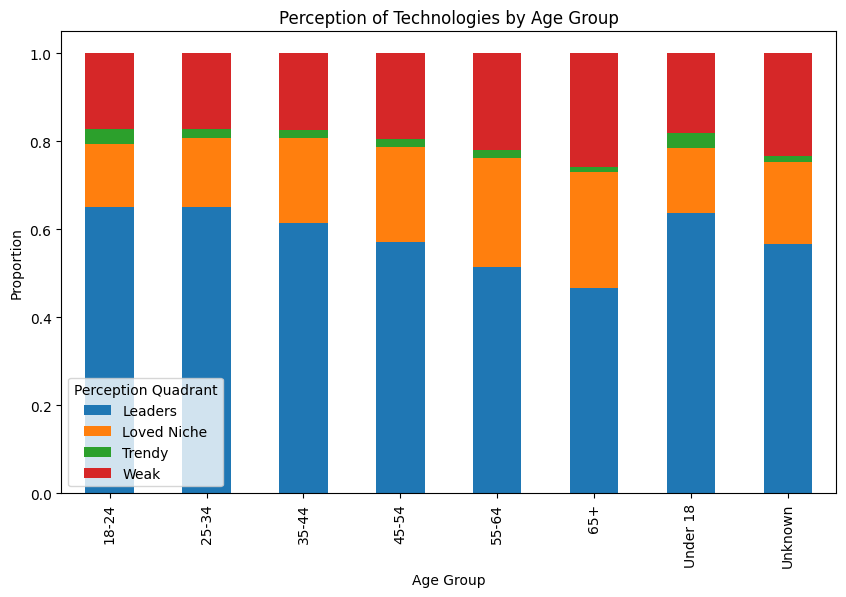

In [34]:
ct = pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize='index'
)

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)
order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
ct = ct.loc[order]

plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.title('Perception of Technologies by Age Group')
plt.legend(title = 'Perception Quadrant')
plt.show()

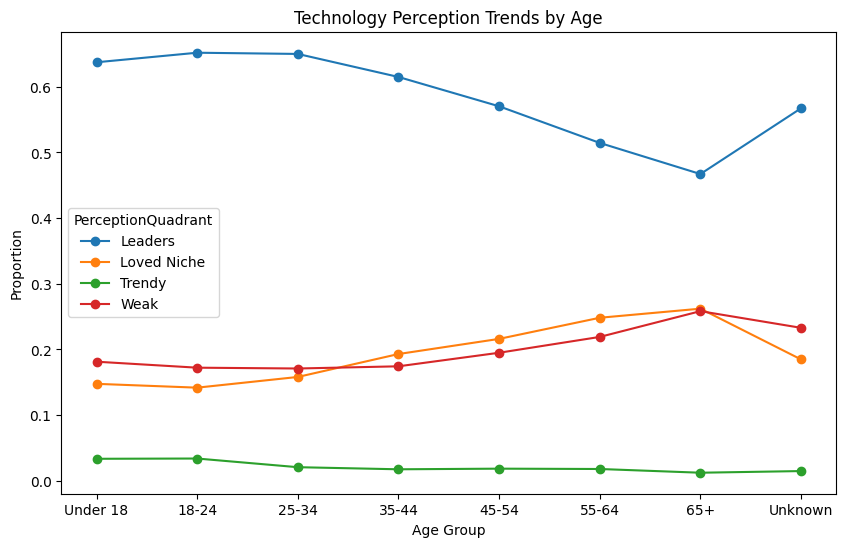

In [35]:
ct = pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize='index'
)

order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
ct = ct.loc[order]

ct.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)

plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.title('Technology Perception Trends by Age')
plt.show()

- La percepción de tecnologías líderes predomina en todos los grupos de edad, alcanzando sus niveles más altos entre los desarrolladores de 18 a 34 años.
- A medida que aumenta la edad, crece la proporción de tecnologías percibidas como nicho o en declive, lo que podría reflejar una mayor permanencia o especialización en herramientas específicas.
- Las tecnologías clasificadas como trendy presentan la menor proporción en todos los grupos de edad, lo que sugiere que relativamente pocas herramientas son percibidas principalmente como tendencias emergentes.